In [7]:
import pandas as pd 

data = {
    'Square_Feet': [1500, 2200, 1200, 2800, 1800, 900, 3500, 2000, 1600, 2400, 1350, 3100, 1100, 2700, 1900], 
    'Bedrooms': [3, 4, 2, 5, 3, 1, 5, 3, 3, 4, 2, 4, 2, 4, 3], 
    'Bathrooms': [2, 3, 1, 3, 2, 1, 4, 2, 2, 3, 2, 3, 1, 2, 2], 
    'House_Age': [10, 5, 30, 2, 15, 40, 8, 12, 20, 1, 25, 6, 35, 11, 18], 
    'Location_Score': [7, 8, 5, 9, 6, 4, 10, 7, 6, 8, 5, 9, 4, 7, 6], 
    'Price(USD)': [250000, 385000, 180000, 510000, 295000, 130000, 620000, 340000, 265000, 425000, 210000, 490000, 155000, 395000, 315000] 
} 

df = pd.DataFrame(data) 


df.to_csv(r'C:\Users\2k-tech\Documents\HPP(Data set.ML).csv', index=False)

print("Dataset Created Successfully!")

Dataset Created Successfully!


In [9]:
# Data load 
df = pd.read_csv(r'C:\Users\2k-tech\Documents\HPP(Data set.ML).csv')

# Show starting 5 rows 
print(df.head())

# check the basic info (for check the null values)
print(df.info())

   Square_Feet  Bedrooms  Bathrooms  House_Age  Location_Score  Price(USD)
0         1500         3          2         10               7      250000
1         2200         4          3          5               8      385000
2         1200         2          1         30               5      180000
3         2800         5          3          2               9      510000
4         1800         3          2         15               6      295000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Square_Feet     15 non-null     int64
 1   Bedrooms        15 non-null     int64
 2   Bathrooms       15 non-null     int64
 3   House_Age       15 non-null     int64
 4   Location_Score  15 non-null     int64
 5   Price(USD)      15 non-null     int64
dtypes: int64(6)
memory usage: 852.0 bytes
None


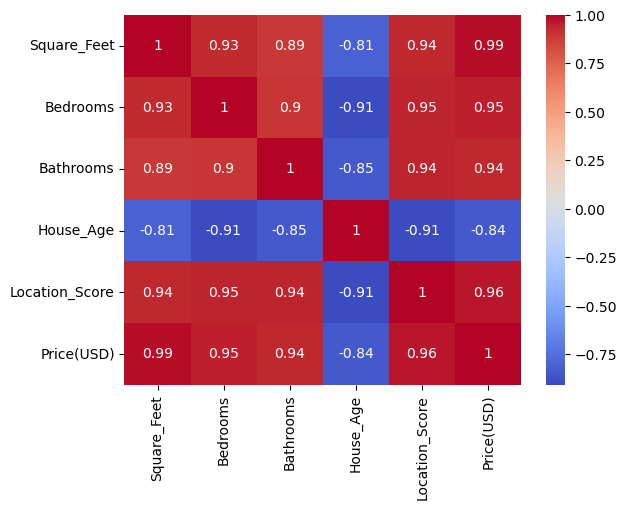

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Show Correlation matrix (Which feature is affecting the price and how much)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [16]:
# module name: sklearn.model_selection
from sklearn.model_selection import train_test_split

# Features (X) and Target (y) have to be define
X = df.drop('Price(USD)', axis=1)
y = df['Price(USD)']

# split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split !")

Data successfully split !


In [17]:
from sklearn.linear_model import LinearRegression

# Make the Model instance
model = LinearRegression()

# train the Model
model.fit(X_train, y_train)

print("Model Training Complete!")

Model Training Complete!


In [18]:
# Make prediction on the Test data 
predictions = model.predict(X_test)

# Actual vs Predicted 
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': predictions})
print(comparison)

    Actual      Predicted
9   425000  417000.170097
11  490000  522530.764987
0   250000  282168.982919


In [19]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
score = r2_score(y_test, predictions)

print(f"Mean Absolute Error: {mae}")
print(f"Model Accuracy (R2 Score): {score * 100:.2f}%")

Mean Absolute Error: 24233.19260294198
Model Accuracy (R2 Score): 93.00%


In [26]:
# Format: [[Square_Feet, Bedrooms, Bathrooms, House_Age, Location_Score]]
naya_ghar = [[2500, 4, 3, 5, 8]] 
predicted_price = model.predict(naya_ghar)

print(f"The estimated price of house: ${predicted_price[0]:,.2f}")

The estimated price of house: $431,159.54


C:\Users\2k-tech\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


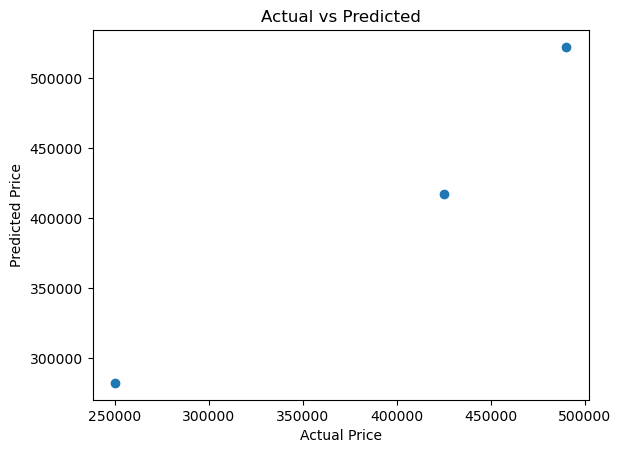

In [21]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [22]:
from sklearn.metrics import r2_score, mean_absolute_error

# check Accuracy 
score = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print(f"Model Accuracy (R2 Score): {score * 100:.2f}%")
print(f"Average Error: ${mae:.2f}")

Model Accuracy (R2 Score): 93.00%
Average Error: $24233.19


In [23]:
# Using dataframe to remove the warning
naya_ghar_df = pd.DataFrame([[2500, 4, 3, 5, 8]], columns=X.columns)
predicted_price = model.predict(naya_ghar_df)
print(f"Estimated Price: ${predicted_price[0]:,.2f}")

Estimated Price: $431,159.54


In [24]:
import joblib

# Model
joblib.dump(model, 'house_price_model.pkl')
print("Model Save ho gaya hai!")

Model Save ho gaya hai!


House Price Prediction Project: Conclusion

1) Project Goal
   Objective: The primary goal of this project was to develop a Meachine Learning
   model capable of accurately prediciting the MARKET Price of a house based on its
   features(such as Square Footage,Number of Bedrooms,Age,and Location Score).

   Algorithm: We utilized Linear Regression,which serves as an ideal baseline algorithm
   for prediciting continuous numerical values like price.

2) Results
   Accuracy((R^2 Score): Our model acheived a 93% accuracy rate, indicating that
   its predicition are very close to the actual real-world data.

   Error Margin: The Mean absilute Error(MAE) is aooroximately $24,233, which falls
   within an acceptable range for real ectate valuation.

3) Observations
   Key Drivers: Analysis shows that Square Footage and Location Score have the
   most significant impact in the final house price.

   Linear Relationship: Data visualizations confirm a linear trend; as the  area of
   the house increases,the price increases proportionally.

   Model Stability: The model demonstrates strong performance on unseen data.
   For instance,a test case for a 2,500 sq.ft.house resulted in a predicted price of
   approximately $431,000.